In [1]:
# -----------------------------------------------------------
# SCENARIO LOOKUP DICTIONARY (METADATA)
# -----------------------------------------------------------

# Full scenario names by marker ID
SCENARIO_LOOKUP = {
    # Natural Faults (1–6)
    1: "Fault L1 (10–19%)",
    2: "Fault L1 (20–79%)",
    3: "Fault L1 (80–90%)",
    4: "Fault L2 (10–19%)",
    5: "Fault L2 (20–79%)",
    6: "Fault L2 (80–90%)",

    # Maintenance (13–14)
    13: "Line Maintenance L1",
    14: "Line Maintenance L2",

    # Data Injection Attacks (7–12)
    7:  "DI: L1 Fault 10–19% with Tripping",
    8:  "DI: L1 Fault 20–79% with Tripping",
    9:  "DI: L1 Fault 80–90% with Tripping",
    10: "DI: L2 Fault 10–19% with Tripping",
    11: "DI: L2 Fault 20–79% with Tripping",
    12: "DI: L2 Fault 80–90% with Tripping",

    # Remote Tripping (15–20)
    15: "RT: Command R1",
    16: "RT: Command R2",
    17: "RT: Command R3",
    18: "RT: Command R4",
    19: "RT: Command R1 & R2",
    20: "RT: Command R3 & R4",

    # Relay Setting Change – Single relay
    21: "RSC: R1 Disabled (L1 10–19%)",
    22: "RSC: R1 Disabled (L1 20–90%)",
    23: "RSC: R2 Disabled (L1 10–49%)",
    24: "RSC: R2 Disabled (L1 50–79%)",
    25: "RSC: R2 Disabled (L1 80–90%)",
    26: "RSC: R3 Disabled (L2 10–19%)",
    27: "RSC: R3 Disabled (L2 20–49%)",
    28: "RSC: R3 Disabled (L2 50–90%)",
    29: "RSC: R4 Disabled (L2 10–79%)",
    30: "RSC: R4 Disabled (L2 80–90%)",

    # Relay Setting Change – Multi relay
    35: "RSC: R1 & R2 Disabled (L1 10–49%)",
    36: "RSC: R1 & R2 Disabled (L1 50–90%)",
    37: "RSC: R3 & R4 Disabled (L1 10–49%)",
    38: "RSC: R3 & R4 Disabled (L1 50–90%)",

    # Relay Setting + Maintenance
    39: "RSC: Maint – R1 & R2 Disabled",
    40: "RSC: Maint – R1 & R2 Disabled",

    # Normal
    41: "Normal Operation"
}

# Short names (helpful for plots)
DI_NAMES = {
    7: "DI L1 10–19%",
    8: "DI L1 20–79%",
    9: "DI L1 80–90%",
    10: "DI L2 10–19%",
    11: "DI L2 20–79%",
    12: "DI L2 80–90%"
}

RT_NAMES = {
    15: "RT R1", 16: "RT R2", 17: "RT R3", 18: "RT R4",
    19: "RT R1&R2", 20: "RT R3&R4"
}

RSC_NAMES = {
    21: "RSC R1 Off (L1 10–19%)",
    22: "RSC R1 Off (L1 20–90%)",
    23: "RSC R2 Off (L1 10–49%)",
    24: "RSC R2 Off (L1 50–79%)",
    25: "RSC R2 Off (L1 80–90%)",
    26: "RSC R3 Off (L2 10–19%)",
    27: "RSC R3 Off (L2 20–49%)",
    28: "RSC R3 Off (L2 50–90%)",
    29: "RSC R4 Off (L2 10–79%)",
    30: "RSC R4 Off (L2 80–90%)",
    35: "RSC R1&R2 Off (L1 10–49%)",
    36: "RSC R1&R2 Off (L1 50–90%)",
    37: "RSC R3&R4 Off (L1 10–49%)",
    38: "RSC R3&R4 Off (L1 50–90%)",
    39: "RSC Maint (R1&R2 Off)",
    40: "RSC Maint (R1&R2 Off)"
}


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

In [5]:
import pandas as pd
import numpy as np
import os

DATA_DIR = "../data/datasets_hierarchical"

datasets = {
    "M1_Attack_vs_NonAttack": "M1_Attack_vs_NonAttack.csv",
    "M2_Natural_3Class": "M2_Natural_3Class.csv",
    "M3_Attack_3Class": "M3_Attack_3Class.csv",
    "M4_DataInjection_Internal": "M4_DataInjection_Internal.csv",
    "M5_RemoteTripping_Internal": "M5_RemoteTripping_Internal.csv",
    "M6_RelaySetting_Internal": "M6_RelaySetting_Internal.csv",
}

cleaned_datasets = {}

print("\n==================== CLEANING RESULTS ====================\n")

for name, filename in datasets.items():

    path = os.path.join(DATA_DIR, filename)
    df = pd.read_csv(path)

    # BEFORE
    original_shape = df.shape

    # Convert Inf → NaN
    df = df.replace([np.inf, -np.inf], np.nan)

    # Fill NaN column-wise median
    df = df.fillna(df.median(numeric_only=True))

    # AFTER
    cleaned_shape = df.shape

    cleaned_datasets[name] = df

    print(f"{name}:")
    print(f"   Before cleaning: {original_shape[0]} rows × {original_shape[1]} columns")
    print(f"   After cleaning:  {cleaned_shape[0]} rows × {cleaned_shape[1]} columns")
    print("   ✔ Cleaned: Inf→NaN→Median filled\n")

print("\n===========================================================\n")


==================== CLEANING RESULTS ====================

M1_Attack_vs_NonAttack:
   Before cleaning: 78377 rows × 131 columns
   After cleaning:  78377 rows × 131 columns
   ✔ Cleaned: Inf→NaN→Median filled

M2_Natural_3Class:
   Before cleaning: 22714 rows × 131 columns
   After cleaning:  22714 rows × 131 columns
   ✔ Cleaned: Inf→NaN→Median filled

M3_Attack_3Class:
   Before cleaning: 55663 rows × 131 columns
   After cleaning:  55663 rows × 131 columns
   ✔ Cleaned: Inf→NaN→Median filled

M4_DataInjection_Internal:
   Before cleaning: 9582 rows × 130 columns
   After cleaning:  9582 rows × 130 columns
   ✔ Cleaned: Inf→NaN→Median filled

M5_RemoteTripping_Internal:
   Before cleaning: 8737 rows × 130 columns
   After cleaning:  8737 rows × 130 columns
   ✔ Cleaned: Inf→NaN→Median filled

M6_RelaySetting_Internal:
   Before cleaning: 37344 rows × 130 columns
   After cleaning:  37344 rows × 130 columns
   ✔ Cleaned: Inf→NaN→Median filled





In [14]:
import os
os.listdir(DATA_DIR)

['M1_Attack_vs_NonAttack.csv',
 '.DS_Store',
 'M5_RemoteTripping_Internal.csv',
 'M2_Natural_3Class.csv',
 'cleaned',
 'M3_Attack_3Class.csv',
 'M6_RelaySetting_Internal.csv',
 '.ipynb_checkpoints',
 'M4_DataInjection_Internal.csv']

In [16]:
import pandas as pd
import numpy as np
import os

# -----------------------------------------------------------
# CLEANED DATA DIRECTORY
# -----------------------------------------------------------
DATA_DIR = "../data/datasets_hierarchical/cleaned"
print("Loading cleaned datasets from:", DATA_DIR)

# -----------------------------------------------------------
# EXPECTED CLEANED DATASET FILENAMES
# -----------------------------------------------------------
datasets = {
    "M1_Attack_vs_NonAttack": "M1_Attack_vs_NonAttack_clean.csv",
    "M2_Natural_3Class": "M2_Natural_3Class_clean.csv",
    "M3_Attack_3Class": "M3_Attack_3Class_clean.csv",
    "M4_DataInjection_Internal": "M4_DataInjection_Internal_clean.csv",
    "M5_RemoteTripping_Internal": "M5_RemoteTripping_Internal_clean.csv",
    "M6_RelaySetting_Internal": "M6_RelaySetting_Internal_clean.csv"
}

cleaned_datasets = {}

# -----------------------------------------------------------
# LOAD ALL DATASETS
# -----------------------------------------------------------
print("\n==================== DATASET LOADING ====================\n")

for name, filename in datasets.items():
    path = os.path.join(DATA_DIR, filename)

    if not os.path.exists(path):
        print(f"❌ ERROR: File not found → {filename}")
        print("   Please check the cleaned folder.")
        continue

    df = pd.read_csv(path)
    cleaned_datasets[name] = df

    print(f"✔ Loaded {name}: {df.shape[0]} rows × {df.shape[1]} columns")

print("\n==========================================================\n")


Loading cleaned datasets from: ../data/datasets_hierarchical/cleaned

==================== DATASET LOADING ====================

✔ Loaded M1_Attack_vs_NonAttack: 78377 rows × 131 columns
✔ Loaded M2_Natural_3Class: 22714 rows × 131 columns
✔ Loaded M3_Attack_3Class: 55663 rows × 131 columns
✔ Loaded M4_DataInjection_Internal: 9582 rows × 130 columns
✔ Loaded M5_RemoteTripping_Internal: 8737 rows × 130 columns
✔ Loaded M6_RelaySetting_Internal: 37344 rows × 130 columns





                 TRAINING FOR DATASET: M1_Attack_vs_NonAttack

Dropping non-numeric columns: ['label_name']

===== M1_Attack_vs_NonAttack - Logistic Regression =====
Accuracy: 0.712171472314366
Precision (macro): 0.6436500658906216
Recall (macro): 0.5091961249206899
Macro F1: 0.4404404951773373

Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.03      0.05      3407
           1       0.71      0.99      0.83      8350

    accuracy                           0.71     11757
   macro avg       0.64      0.51      0.44     11757
weighted avg       0.67      0.71      0.60     11757



/Users/cherylchau/Library/Mobile Documents/com~apple~CloudDocs/FYP-data/myenv/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


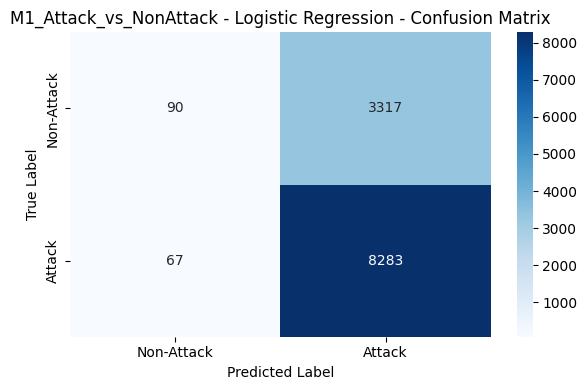


===== M1_Attack_vs_NonAttack - SVM (RBF) =====
Accuracy: 0.7102151909500724
Precision (macro): 0.3551075954750362
Recall (macro): 0.5
Macro F1: 0.4152782613020341

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      3407
           1       0.71      1.00      0.83      8350

    accuracy                           0.71     11757
   macro avg       0.36      0.50      0.42     11757
weighted avg       0.50      0.71      0.59     11757



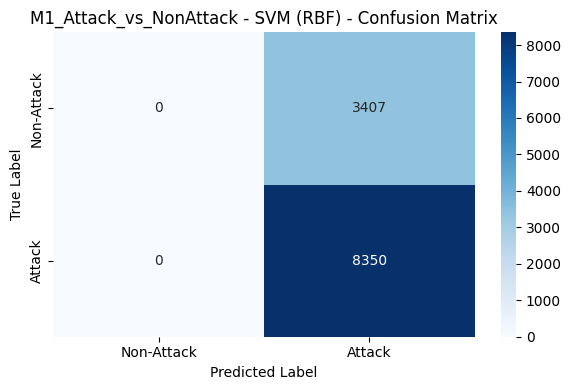


===== M1_Attack_vs_NonAttack - Decision Tree =====
Accuracy: 1.0
Precision (macro): 1.0
Recall (macro): 1.0
Macro F1: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3407
           1       1.00      1.00      1.00      8350

    accuracy                           1.00     11757
   macro avg       1.00      1.00      1.00     11757
weighted avg       1.00      1.00      1.00     11757



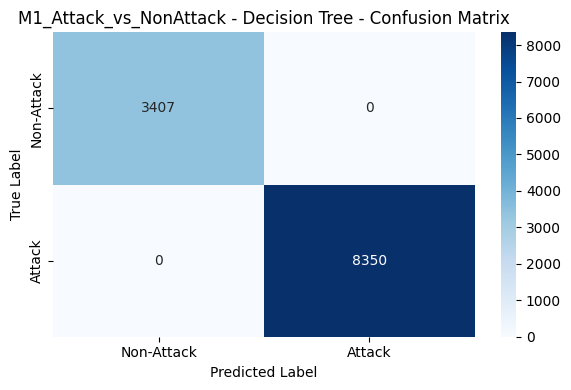


===== M1_Attack_vs_NonAttack - KNN =====
Accuracy: 0.8239346772135749
Precision (macro): 0.7900740137333726
Recall (macro): 0.7701455263819295
Macro F1: 0.7787955149524732

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.64      0.68      3407
           1       0.86      0.90      0.88      8350

    accuracy                           0.82     11757
   macro avg       0.79      0.77      0.78     11757
weighted avg       0.82      0.82      0.82     11757



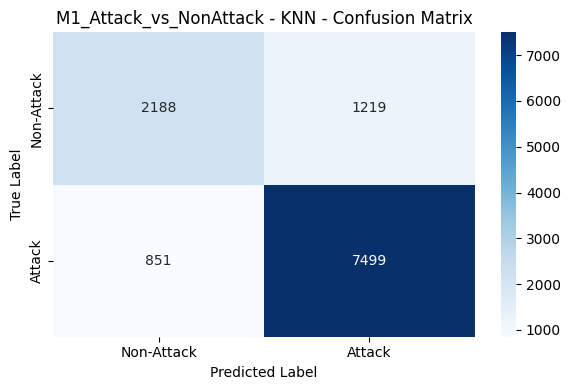


                 TRAINING FOR DATASET: M2_Natural_3Class

Dropping non-numeric columns: ['label_name']

===== M2_Natural_3Class - Logistic Regression =====
Accuracy: 0.7743544600938967
Precision (macro): 0.4981664609684766
Recall (macro): 0.5964547543004426
Macro F1: 0.5426064439064371

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.92      0.85      2250
           1       0.00      0.00      0.00       497
           2       0.69      0.87      0.77       661

    accuracy                           0.77      3408
   macro avg       0.50      0.60      0.54      3408
weighted avg       0.66      0.77      0.71      3408



/Users/cherylchau/Library/Mobile Documents/com~apple~CloudDocs/FYP-data/myenv/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


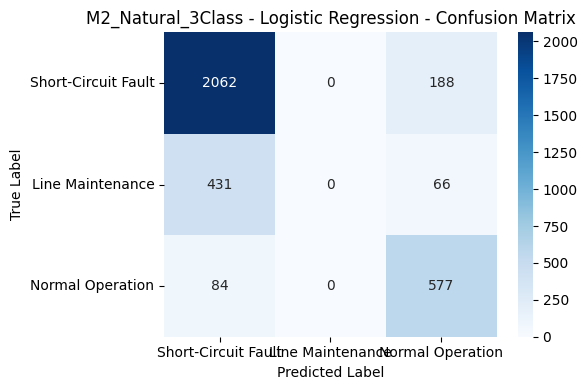


===== M2_Natural_3Class - SVM (RBF) =====
Accuracy: 0.6602112676056338
Precision (macro): 0.22007042253521125
Recall (macro): 0.3333333333333333
Macro F1: 0.2651113467656416

Classification Report:
              precision    recall  f1-score   support

           0       0.66      1.00      0.80      2250
           1       0.00      0.00      0.00       497
           2       0.00      0.00      0.00       661

    accuracy                           0.66      3408
   macro avg       0.22      0.33      0.27      3408
weighted avg       0.44      0.66      0.53      3408



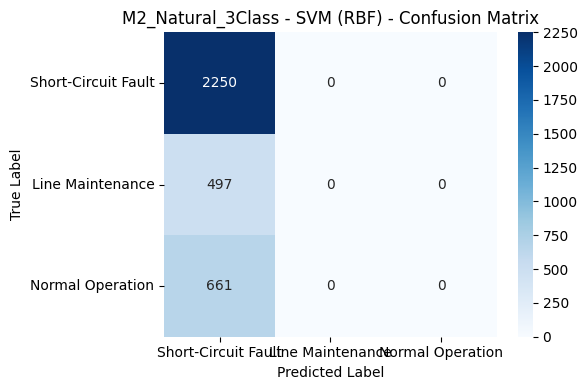


===== M2_Natural_3Class - Decision Tree =====
Accuracy: 1.0
Precision (macro): 1.0
Recall (macro): 1.0
Macro F1: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2250
           1       1.00      1.00      1.00       497
           2       1.00      1.00      1.00       661

    accuracy                           1.00      3408
   macro avg       1.00      1.00      1.00      3408
weighted avg       1.00      1.00      1.00      3408



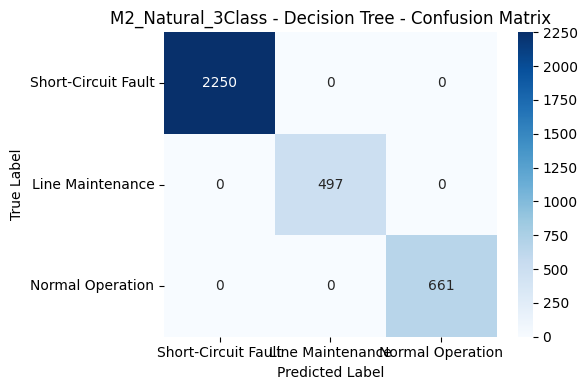


===== M2_Natural_3Class - KNN =====
Accuracy: 0.8324530516431925
Precision (macro): 0.7753130991868026
Recall (macro): 0.7428174123465509
Macro F1: 0.7552705929565381

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.91      0.89      2250
           1       0.64      0.48      0.55       497
           2       0.82      0.84      0.83       661

    accuracy                           0.83      3408
   macro avg       0.78      0.74      0.76      3408
weighted avg       0.82      0.83      0.83      3408



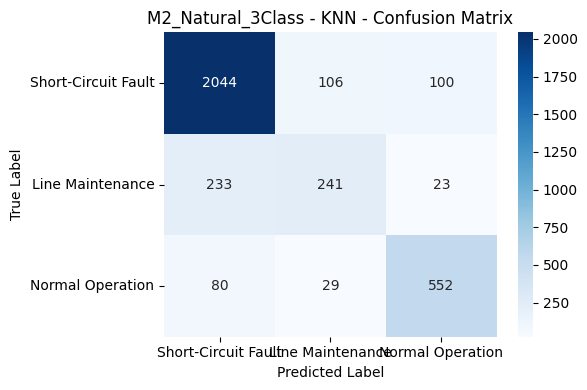


                 TRAINING FOR DATASET: M3_Attack_3Class

Dropping non-numeric columns: ['label_name']

===== M3_Attack_3Class - Logistic Regression =====
Accuracy: 0.6699401197604791
Precision (macro): 0.2654361744697879
Recall (macro): 0.33320191460861465
Macro F1: 0.26850242541785785

Classification Report:
              precision    recall  f1-score   support

           0       0.12      0.00      0.00      1438
           1       0.00      0.00      0.00      1310
           2       0.67      1.00      0.80      5602

    accuracy                           0.67      8350
   macro avg       0.27      0.33      0.27      8350
weighted avg       0.47      0.67      0.54      8350



/Users/cherylchau/Library/Mobile Documents/com~apple~CloudDocs/FYP-data/myenv/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


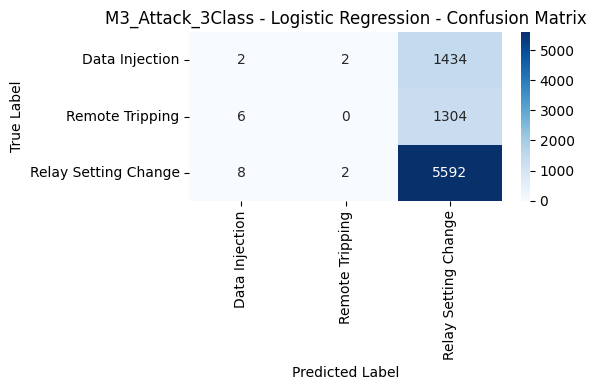


===== M3_Attack_3Class - SVM (RBF) =====
Accuracy: 0.6708982035928144
Precision (macro): 0.22363273453093813
Recall (macro): 0.3333333333333333
Macro F1: 0.2676796636085627

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      1438
           1       0.00      0.00      0.00      1310
           2       0.67      1.00      0.80      5602

    accuracy                           0.67      8350
   macro avg       0.22      0.33      0.27      8350
weighted avg       0.45      0.67      0.54      8350



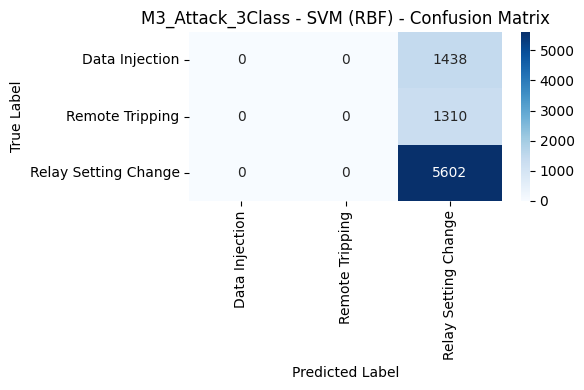


===== M3_Attack_3Class - Decision Tree =====
Accuracy: 1.0
Precision (macro): 1.0
Recall (macro): 1.0
Macro F1: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1438
           1       1.00      1.00      1.00      1310
           2       1.00      1.00      1.00      5602

    accuracy                           1.00      8350
   macro avg       1.00      1.00      1.00      8350
weighted avg       1.00      1.00      1.00      8350



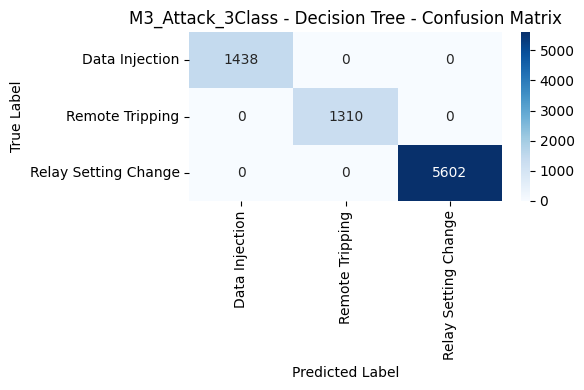


===== M3_Attack_3Class - KNN =====
Accuracy: 0.7948502994011976
Precision (macro): 0.7061427803846554
Recall (macro): 0.7042047257606869
Macro F1: 0.7049866161303607

Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.65      0.64      1438
           1       0.61      0.58      0.60      1310
           2       0.88      0.88      0.88      5602

    accuracy                           0.79      8350
   macro avg       0.71      0.70      0.70      8350
weighted avg       0.79      0.79      0.79      8350



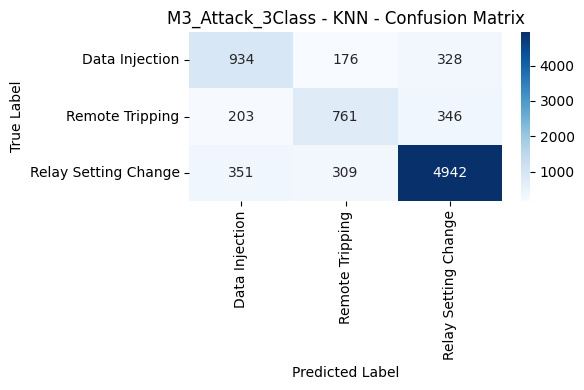


                 TRAINING FOR DATASET: M4_DataInjection_Internal


===== M4_DataInjection_Internal - Logistic Regression =====
Accuracy: 0.4339360222531293
Precision (macro): 0.41706774171610134
Recall (macro): 0.4205859270439157
Macro F1: 0.4050536729057453

Classification Report:
              precision    recall  f1-score   support

           7       0.42      0.62      0.50       214
           8       0.39      0.40      0.40       188
           9       0.37      0.14      0.21       190
          10       0.36      0.26      0.30       263
          11       0.45      0.52      0.48       288
          12       0.51      0.58      0.54       295

    accuracy                           0.43      1438
   macro avg       0.42      0.42      0.41      1438
weighted avg       0.42      0.43      0.42      1438



TypeError: object of type 'NoneType' has no len()

<Figure size 600x400 with 0 Axes>

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------------------------------------
# TRAINING FUNCTIONS
# -----------------------------------------------------------

def stratified_70_15_15_split(X, y, random_state=42):
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.30, stratify=y, random_state=random_state
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=random_state
    )
    return X_train, X_val, X_test, y_train, y_val, y_test


def evaluate_model(name, model, X_train, X_test, y_train, y_test, label_map=None):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    print(f"\n===== {name} =====")
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, average='macro', zero_division=0)
    rec = recall_score(y_test, preds, average='macro', zero_division=0)
    f1_macro = f1_score(y_test, preds, average='macro', zero_division=0)

    print("Accuracy:", acc)
    print("Precision (macro):", prec)
    print("Recall (macro):", rec)
    print("Macro F1:", f1_macro)

    print("\nClassification Report:")
    print(classification_report(y_test, preds, zero_division=0))

    # Confusion Matrix
    cm = confusion_matrix(y_test, preds)

    if label_map:
        labels_sorted = sorted(label_map.keys())
        display_names = [label_map[i] for i in labels_sorted]
    else:
        display_names = None

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=display_names, yticklabels=display_names)
    plt.title(f"{name} - Confusion Matrix")
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.tight_layout()
    plt.show()

    return {
        "Model": name,
        "Accuracy": acc,
        "Precision_macro": prec,
        "Recall_macro": rec,
        "F1_macro": f1_macro
    }


# -----------------------------------------------------------
# LABEL MAPS FOR CONFUSION MATRIX DISPLAY
# -----------------------------------------------------------

label_names_m1 = {0: "Non-Attack", 1: "Attack"}
label_names_m2 = {
    0: "Short-Circuit Fault",
    1: "Line Maintenance",
    2: "Normal Operation"
}
label_names_m3 = {
    0: "Data Injection",
    1: "Remote Tripping",
    2: "Relay Setting Change"
}


# -----------------------------------------------------------
# MAIN TRAINING LOOP FOR ALL DATASETS
# -----------------------------------------------------------

results_summary = []

for dataset_name, df in cleaned_datasets.items():

    print("\n============================================================")
    print(f"                 TRAINING FOR DATASET: {dataset_name}")
    print("============================================================\n")

    # Remove non-numeric columns
    non_numeric_cols = df.select_dtypes(exclude=['number']).columns
    if len(non_numeric_cols) > 0:
        print("Dropping non-numeric columns:", list(non_numeric_cols))
    df = df.drop(columns=non_numeric_cols)

    # Extract labels and features
    y = df["label"]
    X = df.drop(columns=["label"])

    # Assert all numeric
    assert all([np.issubdtype(dtype, np.number) for dtype in X.dtypes]), "Non-numeric still exists!"

    # Split data
    X_train, X_val, X_test, y_train, y_val, y_test = stratified_70_15_15_split(X, y)

    # Model list
    models = {
        "Logistic Regression": LogisticRegression(max_iter=5000, solver="saga"),
        "SVM (RBF)": SVC(kernel='rbf'),
        "Decision Tree": DecisionTreeClassifier(),
        "KNN": KNeighborsClassifier()
    }

    # Label map selection
    if "M1" in dataset_name:
        label_map = label_names_m1
    elif "M2" in dataset_name:
        label_map = label_names_m2
    elif "M3" in dataset_name:
        label_map = label_names_m3
    else:
        label_map = None  # For M4–M6

    # Train models
    for model_name, model in models.items():
        res = evaluate_model(
            f"{dataset_name} - {model_name}",
            model,
            X_train, X_test, y_train, y_test,
            label_map=label_map
        )
        results_summary.append(res)


# -----------------------------------------------------------
# FINAL SUMMARY
# -----------------------------------------------------------

print("\n====================== FINAL SUMMARY ======================\n")
for r in results_summary:
    print(r)


In [ ]:
def load_dataset(path, feature_cols, target_col):
    df = pd.read_csv(path)
    df = clean_dataset(df)
    X = df[feature_cols].copy()
    y = df[target_col].copy()
    return X, y

In [ ]:
def stratified_70_15_15_split(X, y, random_state=42):
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.30, stratify=y, random_state=random_state
    )

    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=random_state
    )

    return X_train, X_val, X_test, y_train, y_val, y_test


In [ ]:
def evaluate_model(name, model, X_train, X_test, y_train, y_test, class_names):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    print(f"\n===== {name} =====")

    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, average='macro', zero_division=0)
    rec = recall_score(y_test, preds, average='macro', zero_division=0)
    f1_macro = f1_score(y_test, preds, average='macro', zero_division=0)

    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("Macro F1:", f1_macro)

    labels_present = np.unique(y_test)
    names_present = [str(class_names[i]) for i in labels_present]

    print("\nClassification Report:")
    print(classification_report(
        y_test, preds, labels=labels_present,
        target_names=names_present, zero_division=0
    ))

    cm = confusion_matrix(y_test, preds, labels=labels_present)

    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=names_present, yticklabels=names_present)
    plt.title(f"{name} - Confusion Matrix")
    plt.tight_layout()
    plt.show()

    return {
        "Model": name,
        "Accuracy": acc,
        "Precision_macro": prec,
        "Recall_macro": rec,
        "F1_macro": f1_macro
    }
